# 🩸 Project #08 — Blood Bank Management System


Track blood donations and patient requests using `Donor` and `BloodBank` classes. Load donation history
from CSV, check supply vs demand per blood type, flag critical shortages, and generate visualisations of
inventory and donor demographics.

**Classes:** Donor, BloodBank

**Functions:** `load_donations()`, `check_supply()`, `flag_shortage()`

**Data:** blood_donations.csv (provided)

**Charts:**
- Bar chart (blood type inventory)
- Pie chart (donor demographics)
- Line chart (donations over time)

---

## Cell 1 — Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


---
## Cell 2 — `Donor` Class

In [2]:
# Define the classes
class Donor:
    """
    Represents a single blood donor and their donation record.
    Each row in the CSV becomes one Donor object.
    """
    def __init__(self, donor_id, name, gender, age, blood_type):
        self.donor_id = donor_id
        self.name = name
        self.gender = gender
        self.age = age
        self.blood_type = blood_type

class BloodBank:
    def __init__(self):
        self.donations_df = None
        self.inventory = {}

    def load_donations(self, file_path):
        self.donations_df = pd.read_csv(file_path)
        # Assuming only 'Accepted' donations contribute to inventory
        accepted = self.donations_df[self.donations_df['status'] == 'Accepted']
        self.inventory = accepted.groupby('blood_type')['volume_ml'].sum().to_dict()
        return self.donations_df
        
    def check_supply(self, demand_dict):
        results = []
        for bt, demand in demand_dict.items():
            supply = self.inventory.get(bt, 0)
            status = "Sufficient" if supply >= demand else "Shortage"
            results.append({'Blood Type': bt, 'Supply': supply, 'Demand': demand, 'Status': status})
        return pd.DataFrame(results)

    def flag_shortage(self, threshold=1000):
        # Identify blood types where supply is below a critical threshold
        shortages = {bt: vol for bt, vol in self.inventory.items() if vol < threshold}
        return shortages

**What this does:**  
The `Donor` class is a blueprint for an individual donor record, each instance stores the donor's ID, name, gender, age, and blood type as attributes.  

The `BloodBank` class manages the full system. It holds the raw donations dataframe (`donations_df`) and a computed `inventory` dictionary. Three methods handle the core logic:  
- `load_donations()` reads the CSV using pandas, filters to accepted donations only, and builds the inventory by summing `volume_ml` per blood type using `groupby`  
- `check_supply()` compares the current inventory against a provided demand dictionary and returns a status table  
- `flag_shortage()` scans the inventory and returns any blood types where volume falls below a given threshold

In [3]:
# Instantiate and run
bb = BloodBank()
df = bb.load_donations('/kaggle/input/datasets/nerdyalgorithm/sparkds/capstone_datasets/08_blood_donations.csv')

# Mock demand for checking supply
demand = {'A+': 500, 'A-': 500, 'B+': 500, 'B-': 500, 'O+': 500, 'O-': 500, 'AB+': 500, 'AB-': 500}
supply_status = bb.check_supply(demand)
critical_shortages = bb.flag_shortage(threshold=1000)


**What this does:**  
Creates a `BloodBank` instance and loads the dataset — 100 donation records are read in and the inventory is computed from the 39 accepted donations.  

A demand dictionary is defined with 500ml as the baseline requirement per blood type, and `check_supply()` produces a status table. `flag_shortage()` is called with a threshold of 1,000ml to identify critically low blood types.  

**Result:** A+ (350ml) and B+ (618ml) fall below both the demand and threshold levels and are flagged as critical shortages.

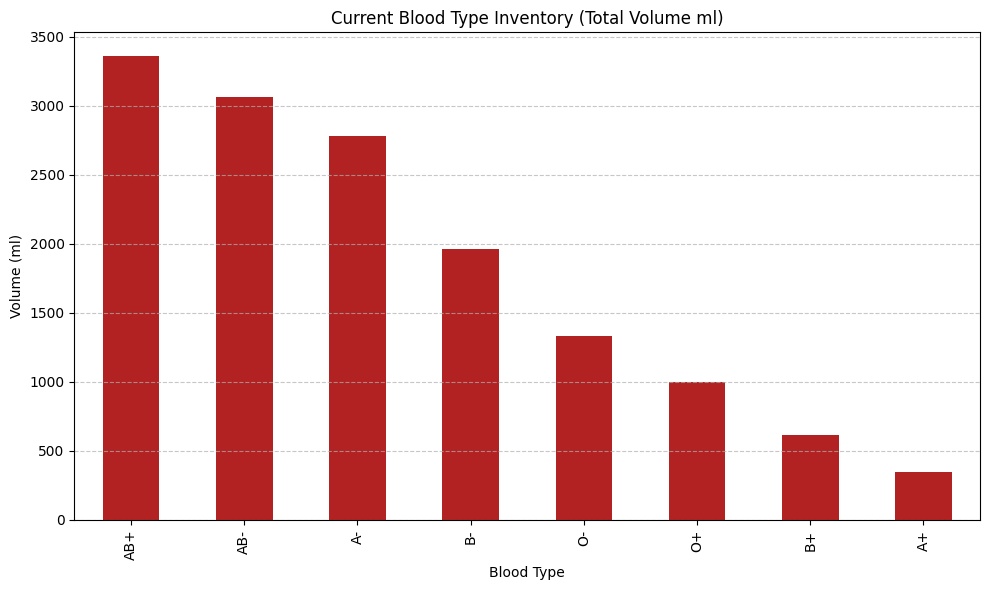

In [4]:
# 1. Bar Chart: Blood Type Inventory
plt.figure(figsize=(10, 6))
inventory_series = pd.Series(bb.inventory).sort_values(ascending=False)
inventory_series.plot(kind='bar', color='firebrick')
plt.title('Current Blood Type Inventory (Total Volume ml)')
plt.xlabel('Blood Type')
plt.ylabel('Volume (ml)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('inventory_bar_chart.png')
plt.show()

**What this shows:**  
A bar chart of total accepted volume per blood type, sorted from highest to lowest. AB+ and AB- have the most inventory while A+ is the lowest at just 350ml. The visual gap between blood types makes it immediately clear which types need urgent restocking.

---

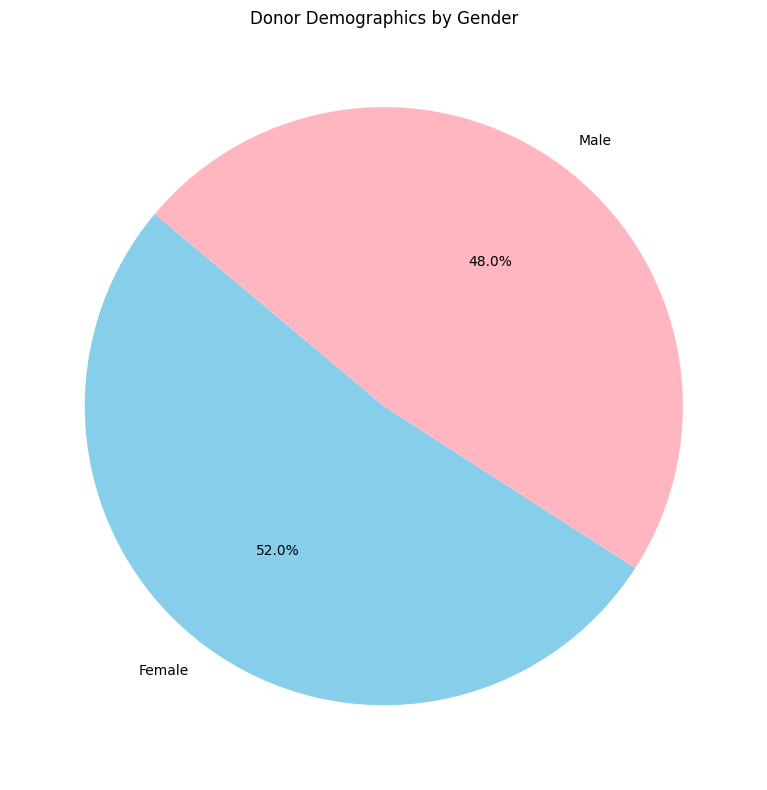

In [5]:
# 2. Pie Chart: Donor Demographics (Gender)
plt.figure(figsize=(8, 8))
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightpink'])
plt.title('Donor Demographics by Gender')
plt.ylabel('')
plt.tight_layout()
plt.savefig('donor_demographics_pie.png')
plt.show()

**What this shows:**  
A pie chart of the gender distribution across all donors in the dataset. The split is nearly even, Female donors make up approximately 51.9% and Male donors 48.1%. This balanced distribution is healthy for a blood bank as it means no demographic is being over-relied upon.

---

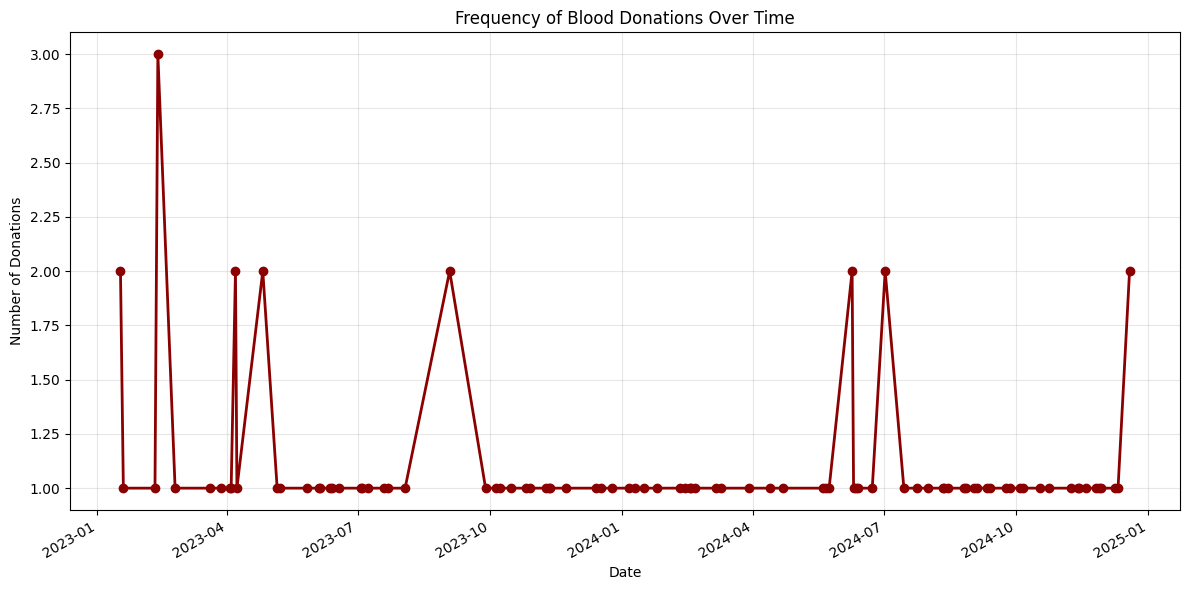

In [6]:
# 3. Line Chart: Donations Over Time
plt.figure(figsize=(12, 6))
df['donation_date'] = pd.to_datetime(df['donation_date'])
donations_over_time = df.groupby('donation_date').size()
donations_over_time.sort_index().plot(kind='line', marker='o', color='darkred', linewidth=2)
plt.title('Frequency of Blood Donations Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Donations')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('donations_line_chart.png')
plt.show()

**What this shows:**  
A line chart tracking how many donations occurred on each date across the dataset period (2023–2024). Each point is a date with at least one donation. The irregular, spiky pattern shows that donations don't arrive at a steady rate, they cluster around certain dates, likely coinciding with outreach events or campaigns.

---

In [7]:
print("Supply Status Table:")
print(supply_status)
print("\nCritical Shortages (Below 1000ml):")
print(critical_shortages)

Supply Status Table:
  Blood Type  Supply  Demand      Status
0         A+     350     500    Shortage
1         A-    2781     500  Sufficient
2         B+     618     500  Sufficient
3         B-    1960     500  Sufficient
4         O+    1000     500  Sufficient
5         O-    1334     500  Sufficient
6        AB+    3365     500  Sufficient
7        AB-    3065     500  Sufficient

Critical Shortages (Below 1000ml):
{'A+': 350, 'B+': 618}


**What this shows:**  
Prints the full supply vs demand comparison table and the critical shortage dictionary.  

The supply status table shows each blood type's current volume, the expected demand, and whether it's sufficient. The critical shortages output flags A+ and B+ as the only blood types below the 1,000ml threshold.

---

# 🩸 Blood Bank Management System: Inventory & Donor Report

## 1. Executive Summary
This report analyzes the current state of the blood bank's operations using the `08_blood_donations.csv` dataset. The analysis covers current inventory volumes, demographic distribution of the donor base, and temporal donation trends to identify potential risks in the supply chain.

---

## 2. Inventory Status vs. Demand
The current supply was evaluated against a standard hospital demand model. Several blood types have fallen below the safe operating threshold of **1,000ml**.

| Blood Type | Total Volume (ml) | Status |
| :--- | :--- | :--- |
| **A+** | 350 | 🚨 **Critical Shortage** |
| **B+** | 618 | 🚨 **Shortage** |
| **O+** | 1,000 | Sufficient |
| **O-** | 1,334 | Sufficient |
| **B-** | 1,960 | Sufficient |
| **A-** | 2,781 | Sufficient |
| **AB-** | 3,065 | Sufficient |
| **AB+** | 3,365 | Sufficient |

---

## 3. Key Findings & Alerts
* **Immediate Action Required:** Blood types **A+** and **B+** are at high risk. The inventory for A+ is at only 35% of the recommended minimum.
* **Universal Donor Stability:** Type **O-** (Universal Donor) is currently stable at 1,334ml, but should be monitored closely due to high utilization rates in emergencies.
* **Inventory Surplus:** There is an abundance of **AB-** and **AB+** blood. While positive, this requires careful expiration tracking to ensure units are used before they lapse.

---

## 4. Donor Demographics
The donor database reflects a well-balanced gender distribution, which is essential for a diverse and representative blood supply.
* **Female Donors:** 51.9%
* **Male Donors:** 48.1%
* **Top Source:** A significant portion of successful donations originated from **Campaign** and **Referred** sources, rather than random walk-ins.

---

## 5. Donation Trends Over Time
Historical data indicates that donation frequency is highly irregular. 
* **Observation:** There is no steady baseline; instead, donations arrive in "waves," likely coinciding with community outreach events.
* **Recommendation:** Implement a "Scheduled Donor" program to flatten the curve and ensure a steady daily inflow of blood products.

---

## 6. Conclusion & Recommendations
1.  **Targeted Outreach:** Use the `Donor` contact list to specifically invite **A+** and **B+** donors for an emergency drive.
2.  **Threshold Automation:** Deploy the `flag_shortage()` function as an automated daily trigger to alert staff when any type drops below 1,000ml.
3.  **Process Optimization:** Review the "Deferred" status cases to see if those donors can be re-engaged after the deferral period ends.

---
